In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import os
from glob import glob

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "lines.linewidth": 2,
    "lines.markersize": 6,
    "figure.figsize": (5, 4),
})


In [2]:
# ==========================================
# 1. Helpers for postprocessed AN/node spectra
# ==========================================

base_dir = "./"

def discover_temperatures(base_dir="./"):
    summary = os.path.join(base_dir, "summary_all.csv")
    if os.path.exists(summary):
        df = pd.read_csv(summary)
        return np.sort(df['T'].dropna().unique())
    vals = []
    for path in glob(os.path.join(base_dir, "T_*")):
        try:
            vals.append(float(os.path.basename(path).split("_", 1)[1]))
        except ValueError:
            pass
    return np.array(sorted(vals))

def find_T_dir(T, base_dir="./"):
    candidates = [f"T_{T}", f"T_{T:g}", f"T_{T:.3f}", f"T_{T:.2f}"]
    for name in candidates:
        path = os.path.join(base_dir, name)
        if os.path.isdir(path):
            return path
    return os.path.join(base_dir, f"T_{T:g}")

def read_omega0_series(data_dir, filename, value_col, err_col='Error'):
    file_path = os.path.join(data_dir, filename)
    if not os.path.exists(file_path):
        print(f"Warning: File not found {file_path}")
        return np.nan, np.nan, np.nan
    df = pd.read_csv(file_path).sort_values('omega')
    idx0 = int(np.argmin(np.abs(df['omega'].to_numpy())))
    err = df[err_col].iloc[idx0] if err_col in df.columns else np.nan
    return df[value_col].iloc[idx0], err, df['omega'].iloc[idx0]

def read_series(data_dir, filename, value_col):
    file_path = os.path.join(data_dir, filename)
    if not os.path.exists(file_path):
        return None
    df = pd.read_csv(file_path).sort_values('omega')
    err = df['Error'].to_numpy(dtype=float) if 'Error' in df.columns else None
    return df['omega'].to_numpy(dtype=float), df[value_col].to_numpy(dtype=float), err

def read_peak_summary(data_dir):
    path = os.path.join(data_dir, 'spectra_path_peaks.csv')
    if not os.path.exists(path):
        return pd.DataFrame()
    return pd.read_csv(path)

def symmetrize_series(omega, vals, err=None):
    order = np.argsort(omega)
    omega = np.asarray(omega, dtype=float)[order]
    vals = np.asarray(vals, dtype=float)[order]
    vals_mirror = np.interp(-omega, omega, vals, left=np.nan, right=np.nan)
    vals_sym = 0.5 * (vals + vals_mirror)
    if err is None:
        return omega, vals_sym, None
    err = np.asarray(err, dtype=float)[order]
    err_mirror = np.interp(-omega, omega, err, left=np.nan, right=np.nan)
    err_sym = 0.5 * np.sqrt(err**2 + err_mirror**2)
    return omega, vals_sym, err_sym

def estimate_tc_from_summary(base_dir="./", rho_col='Superfluid_Stiffness_mean'):
    summary = os.path.join(base_dir, "summary_all.csv")
    if not os.path.exists(summary):
        return np.nan
    df = pd.read_csv(summary).sort_values('T')
    if rho_col not in df.columns or len(df) < 2:
        return np.nan
    T = df['T'].to_numpy(dtype=float)
    diff = df[rho_col].to_numpy(dtype=float) - (2.0 / np.pi) * T
    finite = np.isfinite(T) & np.isfinite(diff)
    T = T[finite]
    diff = diff[finite]
    if len(T) < 2:
        return np.nan
    for i in range(len(T) - 1):
        if diff[i] == 0:
            return float(T[i])
        if diff[i] * diff[i + 1] <= 0:
            return float(T[i] - diff[i] * (T[i + 1] - T[i]) / (diff[i + 1] - diff[i]))
    return np.nan

def temperature_norm(T_values):
    T_values = np.asarray(T_values, dtype=float)
    cmap = plt.cm.turbo
    if len(T_values) > 1 and np.nanmax(T_values) > np.nanmin(T_values):
        norm = mcolors.Normalize(vmin=np.nanmin(T_values), vmax=np.nanmax(T_values))
    else:
        t0 = float(T_values[0]) if len(T_values) else 0.0
        norm = mcolors.Normalize(vmin=t0 - 1e-12, vmax=t0 + 1e-12)
    return cmap, norm

def nearest_temperature(T_values, target):
    T_values = np.asarray(T_values, dtype=float)
    if len(T_values) == 0 or not np.isfinite(target):
        return np.nan
    return float(T_values[np.nanargmin(np.abs(T_values - target))])


In [3]:
# ==========================================
# 2. Main loop
# ==========================================

T_list = discover_temperatures(base_dir)
T_list = T_list[(T_list >= 0.005) & (T_list <= 0.100)]
Tc = estimate_tc_from_summary(base_dir)
T_near_Tc = nearest_temperature(T_list, Tc)

results = {
    "T": [],
    "AN0": [], "AN0_err": [],
    "node0": [], "node0_err": [],
    "AN_kx": [], "AN_ky": [],
    "node_kx": [], "node_ky": [],
}

for T in T_list:
    data_dir = find_T_dir(T, base_dir)
    print(f"Processing {os.path.basename(data_dir)}...", end='\r')
    an0, an_err, _ = read_omega0_series(data_dir, 'spectra_dos_AN.csv', 'DOS_AN')
    nd0, nd_err, _ = read_omega0_series(data_dir, 'spectra_dos_node.csv', 'DOS_node')
    peaks = read_peak_summary(data_dir)

    results['T'].append(T)
    results['AN0'].append(an0); results['AN0_err'].append(an_err)
    results['node0'].append(nd0); results['node0_err'].append(nd_err)

    for kind, prefix in [('AN', 'AN'), ('node', 'node')]:
        sub = peaks[peaks['kind'] == kind] if not peaks.empty and 'kind' in peaks.columns else pd.DataFrame()
        if len(sub) > 0:
            results[f'{prefix}_kx'].append(sub['kx'].mean())
            results[f'{prefix}_ky'].append(sub['ky'].mean())
        else:
            results[f'{prefix}_kx'].append(np.nan)
            results[f'{prefix}_ky'].append(np.nan)

print()
print("Analysis complete.")
if np.isfinite(Tc):
    print(f"Tc from Kubo-BKT crossing: {Tc:.5f}; highlighted T={T_near_Tc:g}")
for key in results:
    results[key] = np.array(results[key])


Processing T_0.050...
Analysis complete.
Tc from Kubo-BKT crossing: 0.02699; highlighted T=0.025


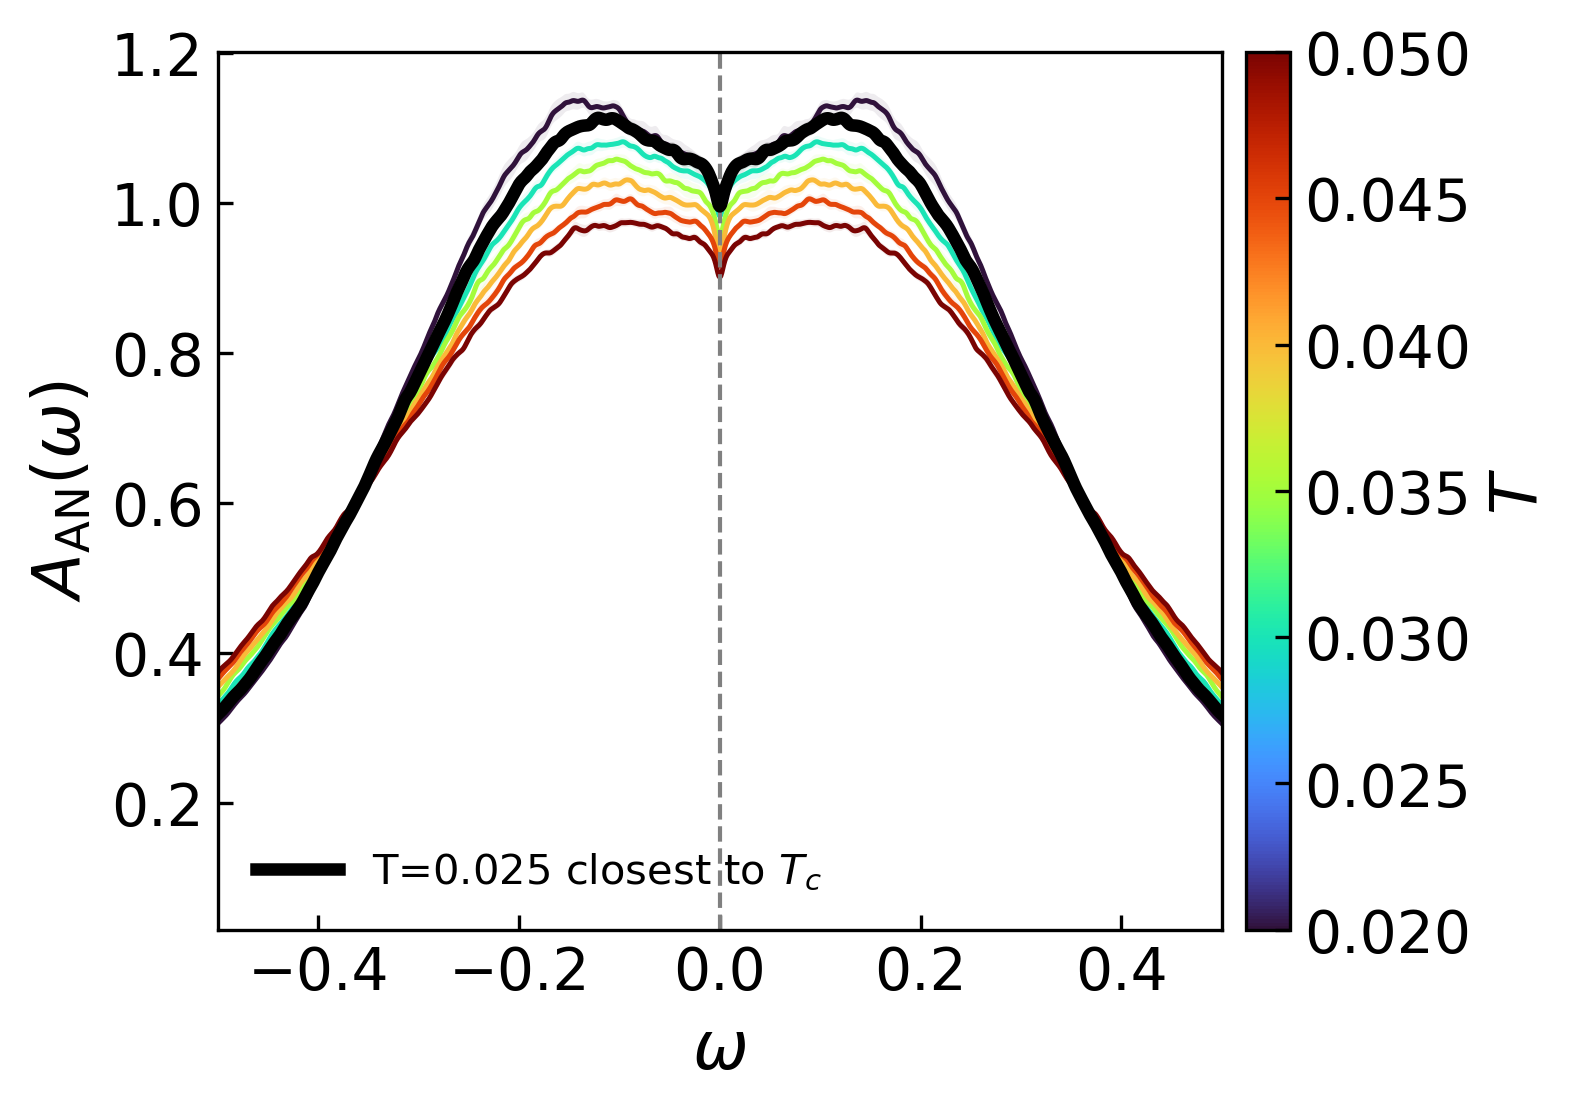

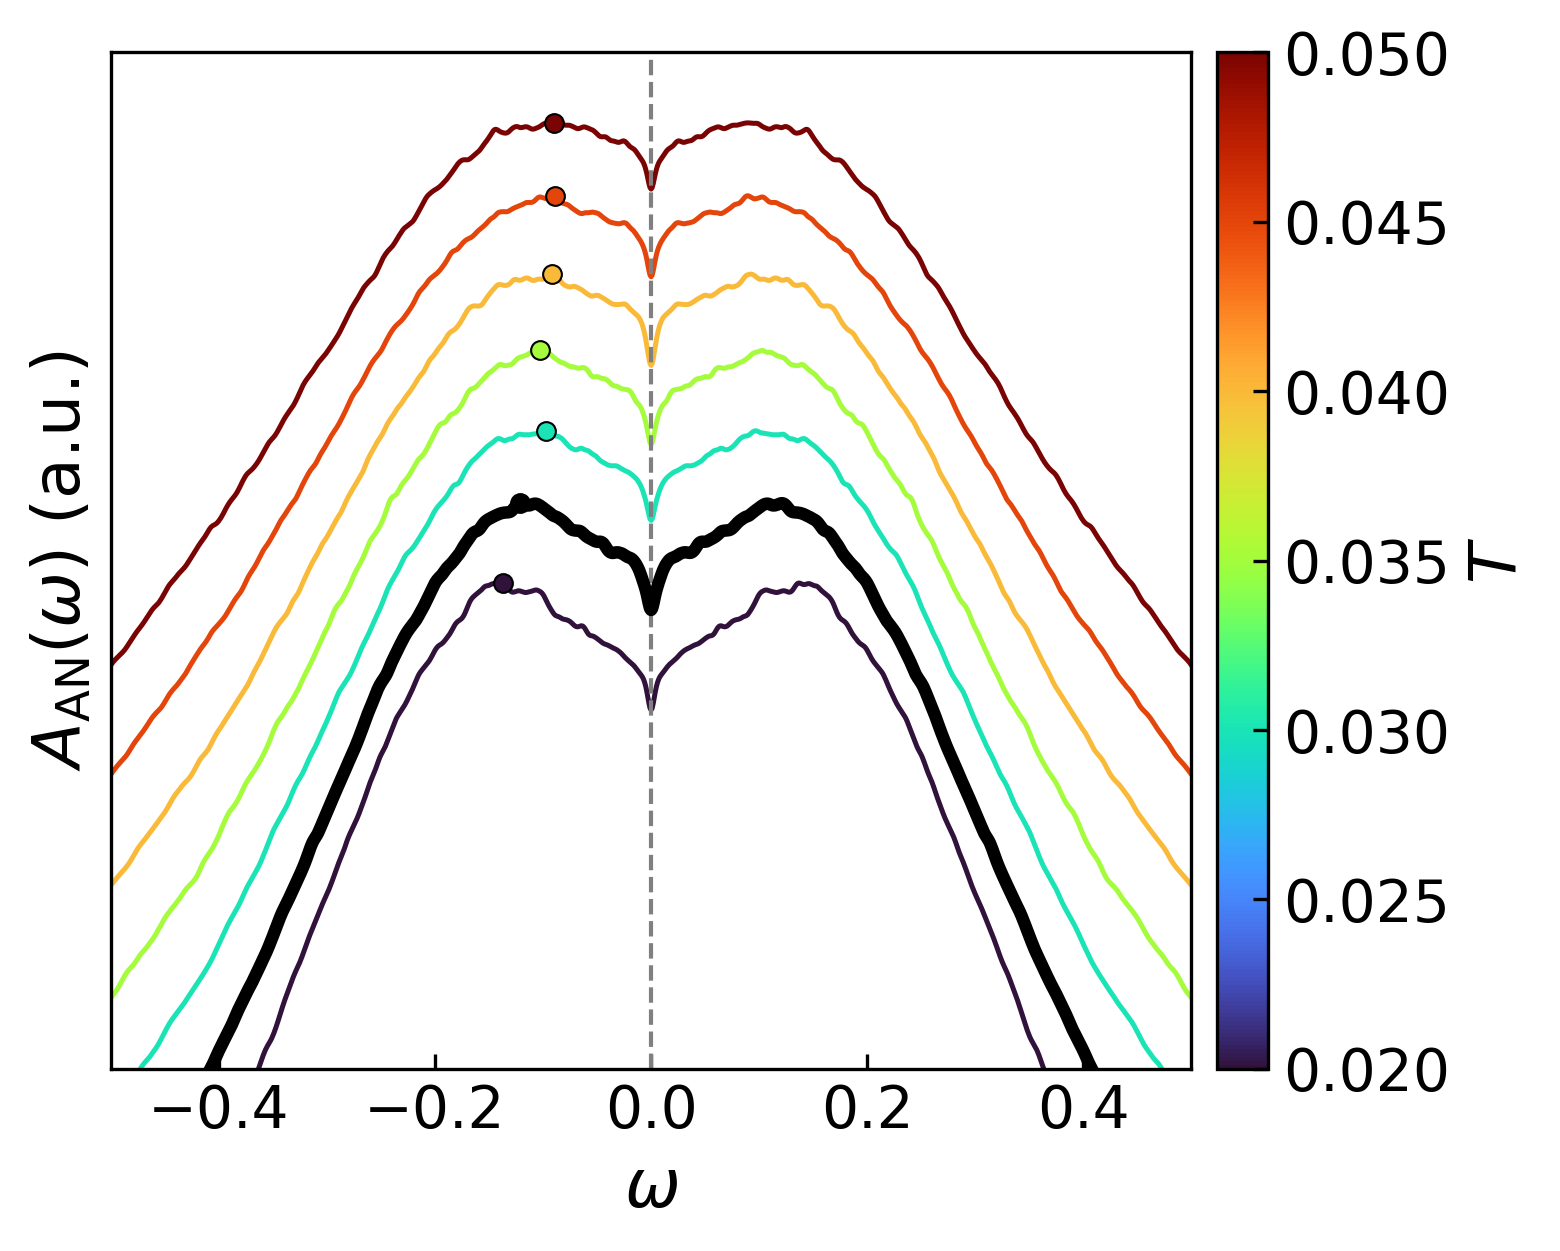

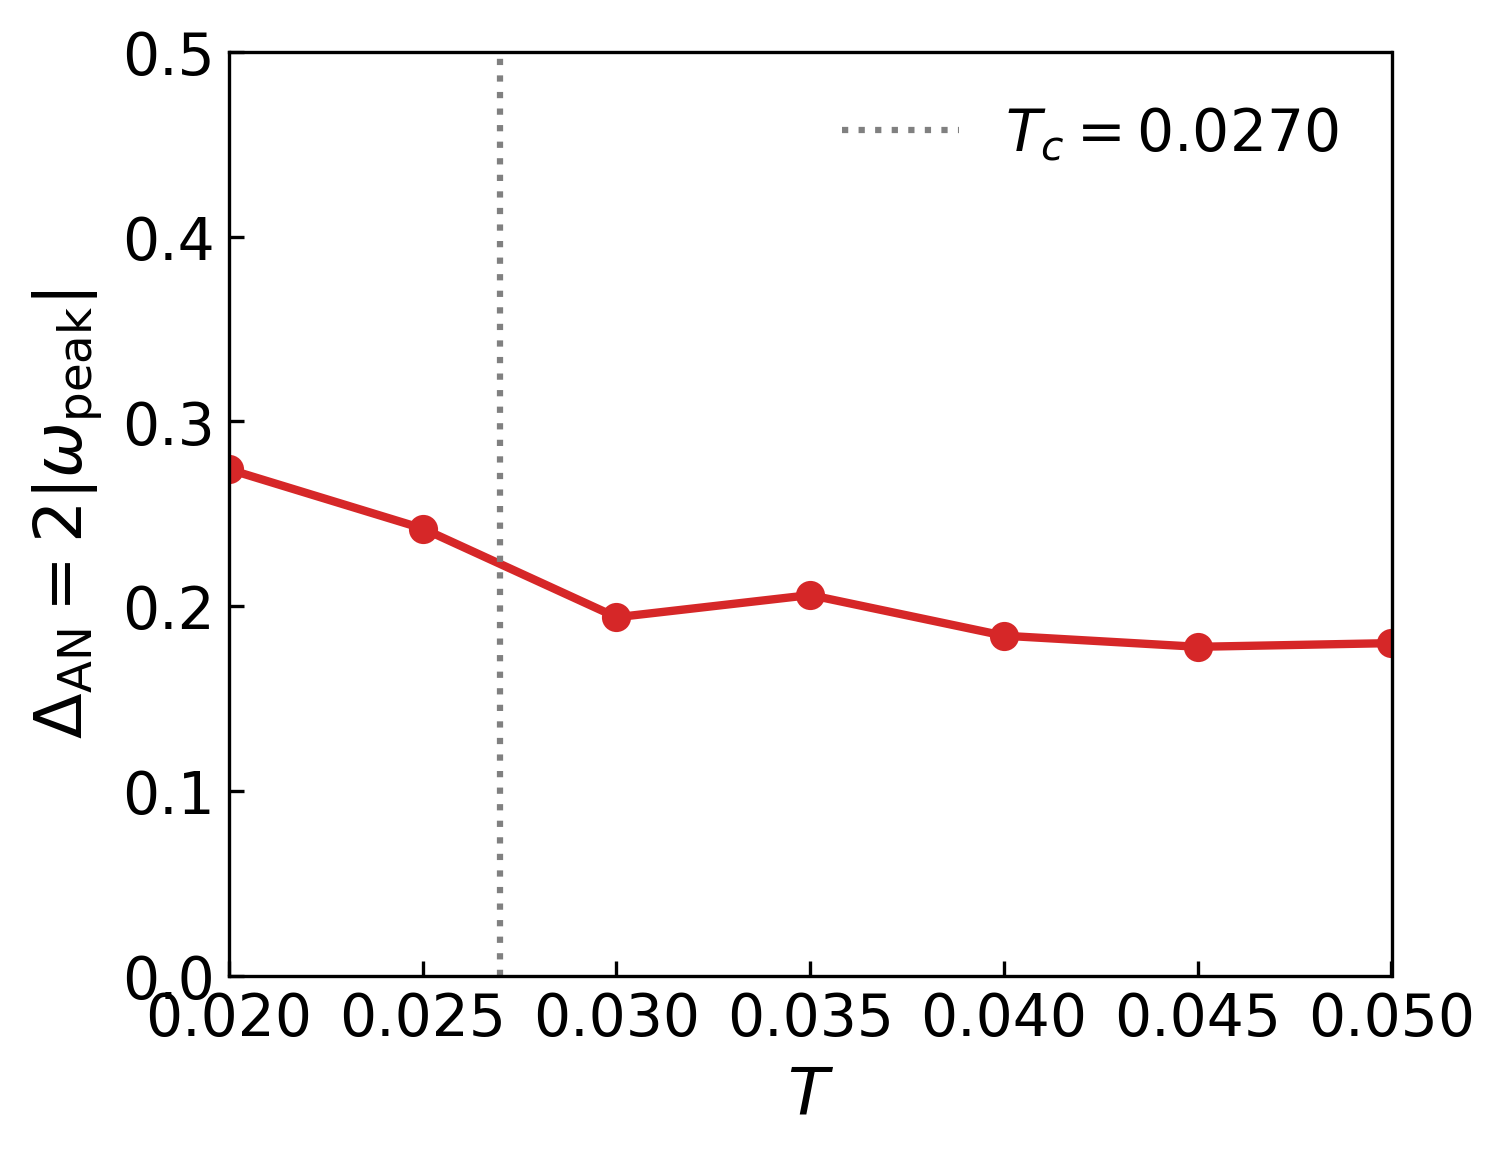

In [4]:
# ==========================================
# 3. Symmetrized A(omega) at postprocessed AN for different T
# ==========================================

if len(T_list) == 0:
    raise RuntimeError("No temperature points found.")

cmap, norm = temperature_norm(T_list)
T_min = float(np.nanmin(T_list))
T_range = float(np.nanmax(T_list) - T_min) if len(T_list) > 1 else 0.0
an_spectra = []
an_peak_rows = []

def plot_symmetrized_curve(ax, omega, vals, err, mask, color, linewidth, zorder, label=None):
    ax.plot(omega[mask], vals[mask], color=color, linewidth=linewidth,
            zorder=zorder, label=label)
    if err is not None:
        mask_err = mask & np.isfinite(err)
        ax.fill_between(omega[mask_err], vals[mask_err] - err[mask_err], vals[mask_err] + err[mask_err],
                        color=color, alpha=0.10 if label is not None else 0.08, linewidth=0)

fig, ax_an = plt.subplots(figsize=(5.2, 3.8), dpi=300)

for T in T_list:
    data_dir = find_T_dir(T, base_dir)
    highlight = np.isfinite(T_near_Tc) and np.isclose(T, T_near_Tc)
    color = 'black' if highlight else cmap(norm(T))
    linewidth = 3.0 if highlight else 1.2
    zorder = 5 if highlight else 2
    label = rf"T={T:g} closest to $T_c$" if highlight else None

    out = read_series(data_dir, 'spectra_dos_AN.csv', 'DOS_AN')
    if out is None:
        continue
    omega, vals, err = symmetrize_series(*out)
    mask = np.isfinite(omega) & np.isfinite(vals)
    an_spectra.append({
        'T': float(T), 'omega': omega, 'vals': vals, 'err': err,
        'mask': mask, 'color': color, 'linewidth': linewidth,
        'zorder': zorder, 'label': label,
    })

    plot_symmetrized_curve(ax_an, omega, vals, err, mask, color, linewidth, zorder, label)

    neg_mask = mask & (omega < 0)
    if np.any(neg_mask):
        neg_indices = np.where(neg_mask)[0]
        peak_idx = neg_indices[int(np.nanargmax(vals[neg_mask]))]
        peak_omega = float(omega[peak_idx])
        peak_val = float(vals[peak_idx])
        an_peak_rows.append({
            'T': float(T),
            'omega_peak_neg': peak_omega,
            'A_peak_neg': peak_val,
            'gap': 2.0 * abs(peak_omega),
        })

    # Optional A_node comparison, commented out by default:
    # node_out = read_series(data_dir, 'spectra_dos_node.csv', 'DOS_node')
    # if node_out is not None:
    #     node_omega, node_vals, node_err = symmetrize_series(*node_out)
    #     node_mask = np.isfinite(node_omega) & np.isfinite(node_vals)
    #     plot_symmetrized_curve(ax_node, node_omega, node_vals, node_err, node_mask,
    #                            color, linewidth, zorder, label)

ax_an.set_xlabel(r'$\omega$')
ax_an.set_ylabel(r'$A_{\mathrm{AN}}(\omega)$')
ax_an.set_xlim(-0.5, 0.5)
ax_an.axvline(0, color='gray', linestyle='--', linewidth=1)
if np.isfinite(T_near_Tc):
    ax_an.legend(frameon=False, fontsize=10)
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax_an, pad=0.02)
cbar.set_label(r'$T$')
plt.show()

# To restore the old two-panel AN/node layout, uncomment this setup and the A_node block above,
# then route the AN calls to ax_an and node calls to ax_node.
# fig, (ax_an, ax_node) = plt.subplots(1, 2, figsize=(9.0, 3.6), dpi=300, sharex=True)
# ax_node.set_xlabel(r'$\omega$')
# ax_node.set_ylabel(r'$A_{\mathrm{node}}(\omega)$')
# ax_node.set_xlim(-0.3, 0.3)
# ax_node.axvline(0, color='gray', linestyle='--', linewidth=1)

an_peak_df = pd.DataFrame(an_peak_rows).sort_values('T').reset_index(drop=True)

finite_vals = np.concatenate([s['vals'][s['mask']] for s in an_spectra]) if an_spectra else np.array([])
if len(finite_vals) > 0:
    robust_span = np.nanpercentile(finite_vals, 95) - np.nanpercentile(finite_vals, 5)
    if not np.isfinite(robust_span) or robust_span <= 0:
        robust_span = np.nanmax(finite_vals) - np.nanmin(finite_vals)
    if not np.isfinite(robust_span) or robust_span <= 0:
        robust_span = 1.0
else:
    robust_span = 1.0

# Manual knobs for the vertically shifted/scaled plot below.
# offset_strength: total vertical offset from Tmin to Tmax, in units of robust A_AN span.
# scale_strength: extra multiplicative scale from Tmin to Tmax; 1.0 means Tmax is plotted as 2*A_AN.
offset_strength = 0.7
scale_strength = 0.0

fig, ax = plt.subplots(figsize=(5.6, 4.4), dpi=300)
for s in an_spectra:
    if T_range > 0:
        t_frac = (s['T'] - T_min) / T_range
        # t_frac = s['T'] / T_range
    else:
        t_frac = 0.0
    amplitude_scale = 1.0 + scale_strength * t_frac
    offset = offset_strength * robust_span * t_frac
    transformed_vals = amplitude_scale * s['vals'] + offset
    ax.plot(s['omega'][s['mask']], transformed_vals[s['mask']], color=s['color'],
            linewidth=s['linewidth'], zorder=s['zorder'])

    peak_match = an_peak_df[np.isclose(an_peak_df['T'], s['T'])]
    if len(peak_match) == 1:
        peak = peak_match.iloc[0]
        peak_y = amplitude_scale * peak['A_peak_neg'] + offset
        ax.plot(peak['omega_peak_neg'], peak_y, 'o',
                color=s['color'], markeredgecolor='black', markeredgewidth=0.5,
                markersize=4.5, zorder=s['zorder'] + 1)

ax.set_xlabel(r'$\omega$')
# ax.set_ylabel(r'$s(T)A_{\mathrm{AN}}(\omega) + b(T)$')
ax.set_ylabel(r'$A_{\mathrm{AN}}(\omega)$ (a.u.)')
ax.set_yticks([])
ax.tick_params(axis='y', left=False, labelleft=False)
ax.set_xlim(-0.5, 0.5)
ax.set_ylim(bottom=0.6)
ax.axvline(0, color='gray', linestyle='--', linewidth=1)
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label(r'$T$')
plt.show()

if len(an_peak_df) == 0:
    print("No negative-omega A_AN peak was found.")
else:
    fig, ax = plt.subplots(dpi=300)
    ax.plot(an_peak_df['T'], an_peak_df['gap'], '-o', color='tab:red')
    if np.isfinite(Tc):
        ax.axvline(x=Tc, color='gray', linestyle=':', linewidth=1.5,
                   label=rf'$T_c={Tc:.4f}$')
    ax.set_xlabel(r'$T$')
    ax.set_ylabel(r'$\Delta_{\mathrm{AN}} = 2|\omega_{\mathrm{peak}}|$')
    ax.set_xlim(0.02, 0.05)
    ax.set_ylim(0,0.5)
    ax.set_ylim(bottom=0)
    ax.legend(loc='best', frameon=False)
    plt.show()


In [5]:
df = pd.read_csv("summary_all.csv").sort_values('T')
Tc = estimate_tc_from_summary(base_dir)
Tc


0.026989748177399263

In [6]:
# fig, ax = plt.subplots(dpi=300)

# ax.errorbar(results["T"], results["val_anti"], yerr=results["err_anti"], 
#             fmt='-o', color='black')

# ax.axvline(x=Tc, color='gray', linestyle=':', linewidth=1.5, label=rf'$T_c$')

# ax.set_xlabel(r'$T$')
# ax.set_ylabel(r'$A(\mathbf{k}=\mathbf{M}, \omega=0)$')
# ax.set_xlim(0,0.08) 
# # ax.set_ylim(0.58,0.76) 
# ax.legend(loc='best', frameon=False)
# plt.show()

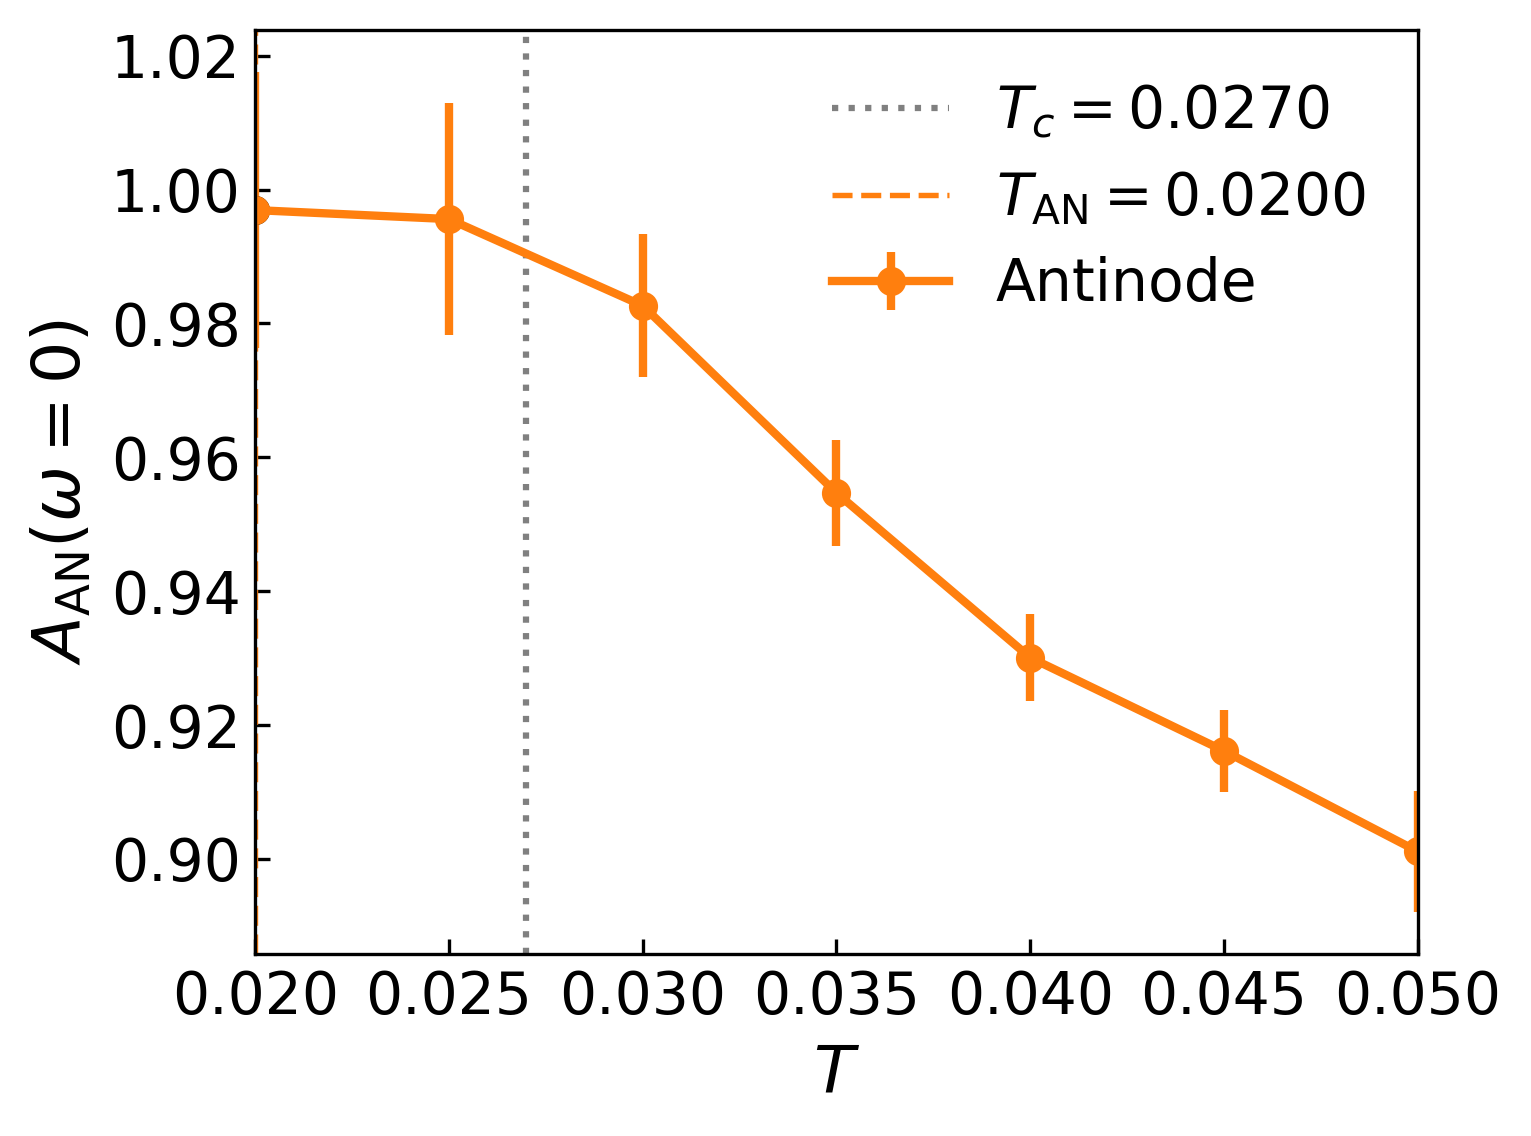

In [7]:
fig, ax = plt.subplots(dpi=300)

ax.errorbar(results["T"], results["AN0"], yerr=results["AN0_err"],
            fmt='-o', color='tab:orange', label=r'Antinode')
# ax.errorbar(results["T"], results["node0"], yerr=results["node0_err"],
#             fmt='-s', color='tab:green', label=r'node from $3\times3$ patch near $\Gamma$-X path')

t_a0 = results["T"].copy()
a0_for_deriv = results["AN0"].copy()
mask_a0 = np.isfinite(t_a0) & np.isfinite(a0_for_deriv)
t_a0 = t_a0[mask_a0]
a0_for_deriv = a0_for_deriv[mask_a0]
order_a0 = np.argsort(t_a0)
t_a0 = t_a0[order_a0]
a0_for_deriv = a0_for_deriv[order_a0]
T_max_dA = np.nan
A0_at_max_dA = np.nan
max_dA_dT = np.nan
if len(t_a0) >= 2:
    dA_dT_for_marker = np.gradient(a0_for_deriv, t_a0)
    finite_dA = np.isfinite(dA_dT_for_marker)
    if np.any(finite_dA):
        finite_indices = np.where(finite_dA)[0]
        max_idx = finite_indices[int(np.nanargmax(dA_dT_for_marker[finite_dA]))]
        T_max_dA = float(t_a0[max_idx])
        A0_at_max_dA = float(a0_for_deriv[max_idx])
        max_dA_dT = float(dA_dT_for_marker[max_idx])

if np.isfinite(Tc):
    ax.axvline(x=Tc, color='gray', linestyle=':', linewidth=1.5, label=rf'$T_c={Tc:.4f}$')
if np.isfinite(T_max_dA):
    ax.axvline(x=T_max_dA, color='tab:orange', linestyle='--', linewidth=1.3,
               label=rf'$T_{{\mathrm{{AN}}}}={T_max_dA:.4f}$')
    ax.plot(T_max_dA, A0_at_max_dA, 'o', color='tab:blue', markeredgecolor='black', markersize=6)

ax.set_xlabel(r'$T$')
ax.set_ylabel(r'$A_{{\mathrm{{AN}}}}(\omega=0)$')
ax.set_xlim(0.02, 0.05)
ax.legend(loc='best', frameon=False)
plt.show()


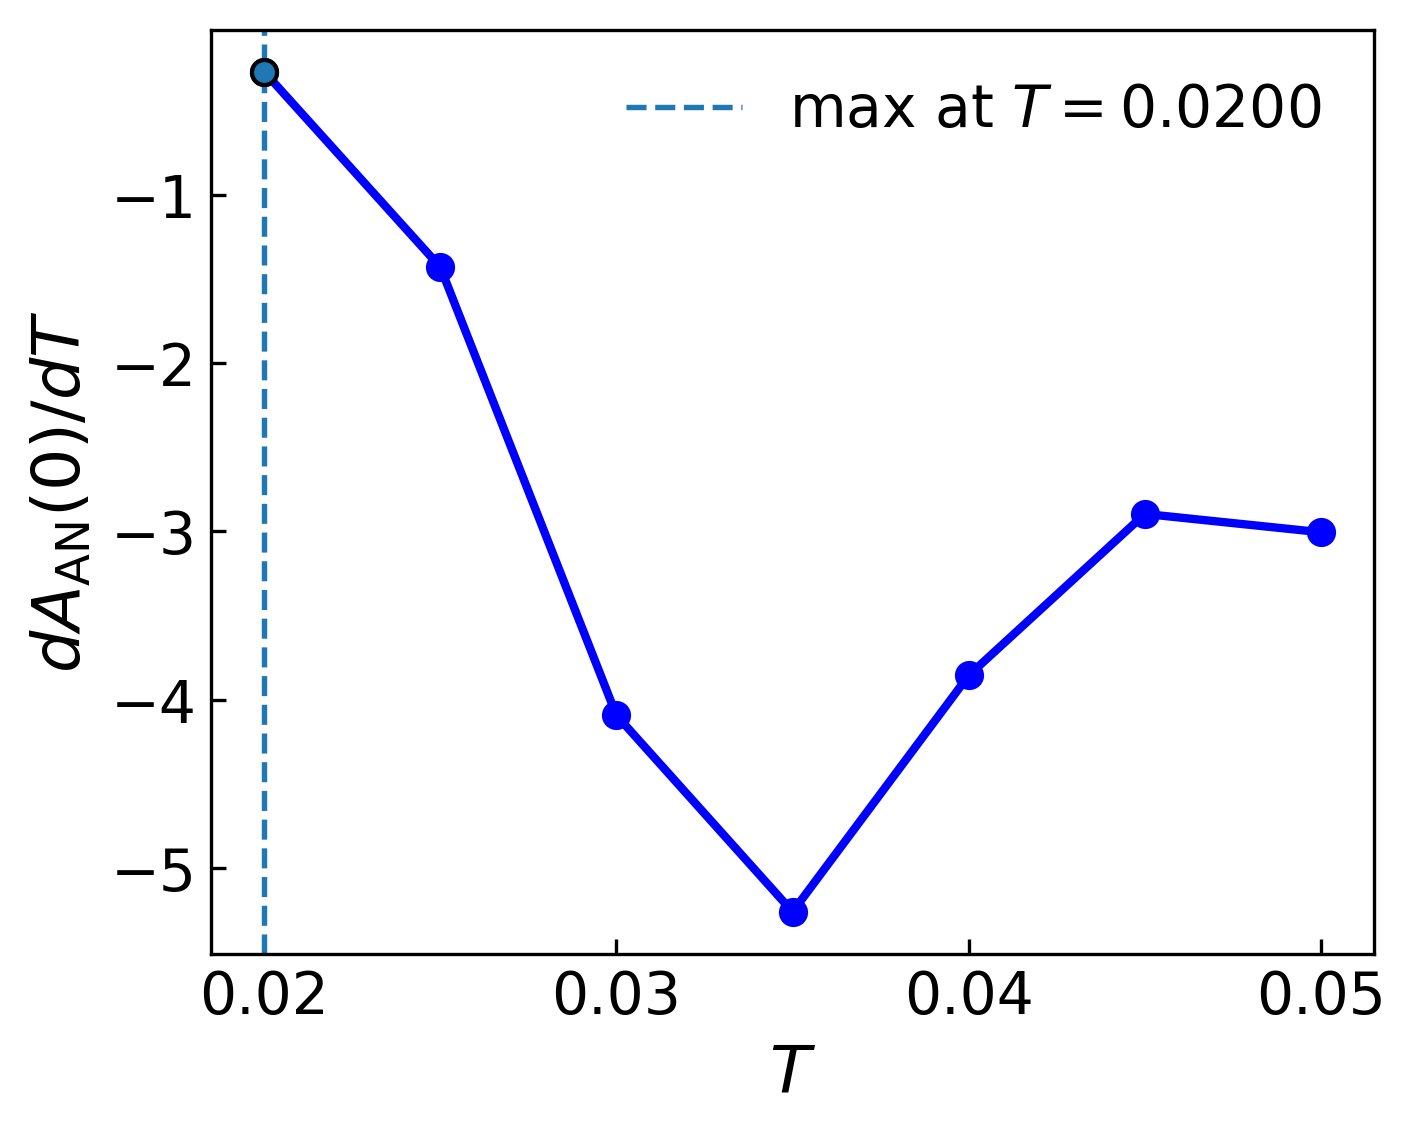

In [8]:
# ==========================================
# 4. dA_AN(omega=0)/dT
# ==========================================

t_vals = results["T"].copy()
a0_vals = results["AN0"].copy()
mask = np.isfinite(t_vals) & np.isfinite(a0_vals)
t_vals = t_vals[mask]
a0_vals = a0_vals[mask]
sort_idx = np.argsort(t_vals)
t_vals = t_vals[sort_idx]
a0_vals = a0_vals[sort_idx]

if len(t_vals) < 2:
    print("Not enough points to compute dA/dT.")
else:
    dA_dT = np.gradient(a0_vals, t_vals)
    finite_dA = np.isfinite(dA_dT)
    T_max_dA = np.nan
    max_dA_dT = np.nan
    if np.any(finite_dA):
        finite_indices = np.where(finite_dA)[0]
        max_idx = finite_indices[int(np.nanargmax(dA_dT[finite_dA]))]
        T_max_dA = float(t_vals[max_idx])
        max_dA_dT = float(dA_dT[max_idx])

    fig, ax = plt.subplots(dpi=300)
    ax.plot(t_vals, dA_dT, '-o', color='blue')
    if np.isfinite(T_max_dA):
        ax.axvline(x=T_max_dA, color='tab:blue', linestyle='--', linewidth=1.3,
                   label=rf'max at $T={T_max_dA:.4f}$')
        ax.plot(T_max_dA, max_dA_dT, 'o', color='tab:blue', markeredgecolor='black', markersize=6)
    ax.set_xlabel(r'$T$')
    ax.set_ylabel(r'$dA_{\mathrm{AN}}(0)/dT$')
    ax.legend(loc='best', frameon=False)
    plt.show()


In [9]:
# fig, ax = plt.subplots(dpi=300)

# contrast = (results["peak_XG"] - results["peak_MX"]) / (results["peak_XG"] + results["peak_MX"])
# contrast_err = np.sqrt( (results["err_XG"]**2 + results["err_MX"]**2) ) / (results["peak_XG"] + results["peak_MX"])

# ax.errorbar(results["T"], contrast, yerr=contrast_err, 
#             fmt='-o', color='black')

# ax.axvline(x=Tc, color='gray', linestyle=':', linewidth=1.5, label=rf'$T_c$')
# ax.axhline(y=0, color='black', linestyle='--', linewidth=1)

# ax.set_xlabel(r'$T$')
# ax.set_ylabel('Fermi surface contrast')
# ax.set_xlim(0,0.2) 
# # ax.set_ylim(-0.01,0.21) 
# ax.legend(loc='best', frameon=False)
# plt.show()